In [1]:
# we want to compare PSDs with the magnet vs PSDs without for UNO

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [3]:
magDF = pd.read_csv('./magrunonpllatform26040300.csv')
# magDF

overDF = pd.read_csv('./26040201A.CSV')

nomagDF = pd.read_csv('./nomagrun26040222.csv')
nomagDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260402_224031_000,81631.000,4159.9785,N,8739.5020,W,8230
1,260402_224031_439,81631.438,4159.9785,N,8739.5020,W,8259
2,260402_224031_449,81631.445,4159.9785,N,8739.5020,W,8262
3,260402_224031_459,81631.461,4159.9785,N,8739.5020,W,8260
4,260402_224031_469,81631.469,4159.9785,N,8739.5020,W,8255
...,...,...,...,...,...,...,...
203065,260402_231631_904,83791.906,4159.9863,N,8739.4414,W,8250
203066,260402_231631_914,83791.914,4159.9863,N,8739.4414,W,8251
203067,260402_231631_924,83791.922,4159.9863,N,8739.4414,W,8250
203068,260402_231631_934,83791.938,4159.9863,N,8739.4414,W,8257


In [4]:
magSeconds = np.array(magDF['seconds'])
magSensor = np.array(magDF['sensor'])

overSeconds = np.array(overDF['seconds'])
overSensor = np.array(overDF['sensor'])

nomagSeconds = np.array(nomagDF['seconds'])
nomagSensor = np.array(nomagDF['sensor'])

In [5]:
overSeconds = overSeconds[200000:-200000]
overSensor = overSensor[200000:-200000]

In [6]:
downoverSec = overSeconds[::5]
downoverSens = overSensor[::5]

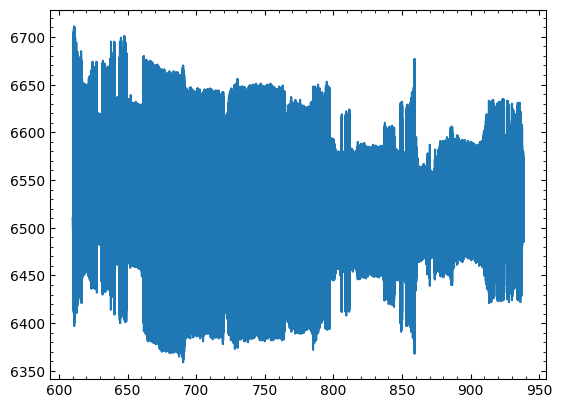

In [7]:
plt.rcParams['text.usetex'] = False
plt.plot(magSeconds,magSensor)

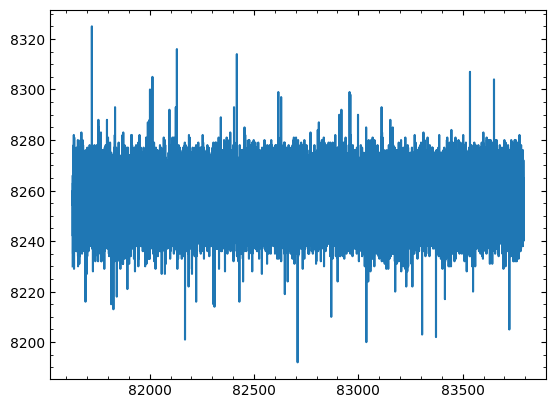

In [8]:
plt.plot(nomagSeconds,nomagSensor)

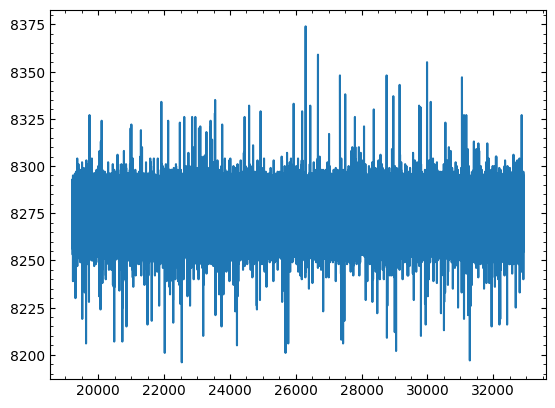

In [9]:
plt.plot(overSeconds,overSensor)

In [10]:
magVolt = magSensor * 5 / 16383
nomagVolt = nomagSensor * 5 / 16383

overVolt = overSensor * 5 / 16383

downoverVolt = downoverSens * 5 / 16383

Text(0, 0.5, 'voltage')

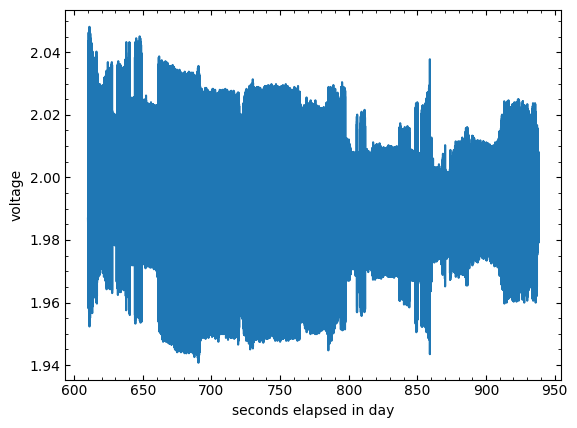

In [11]:
plt.plot(magSeconds,magVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

Text(0, 0.5, 'voltage')

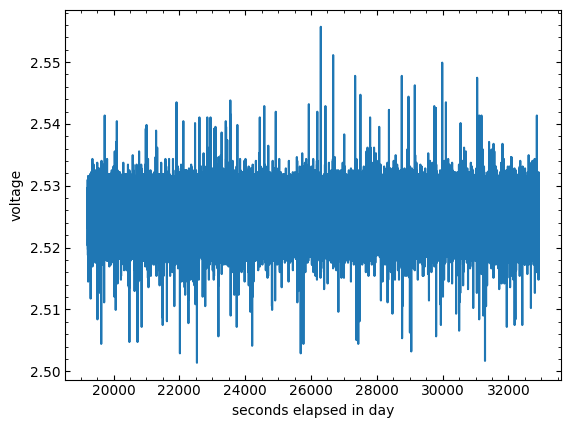

In [12]:
plt.plot(overSeconds,overVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

In [13]:
nomagmask = nomagVolt > 2.5

nomagSeconds = nomagSeconds[nomagmask]
nomagVolt = nomagVolt[nomagmask]

Text(0, 0.5, 'voltage')

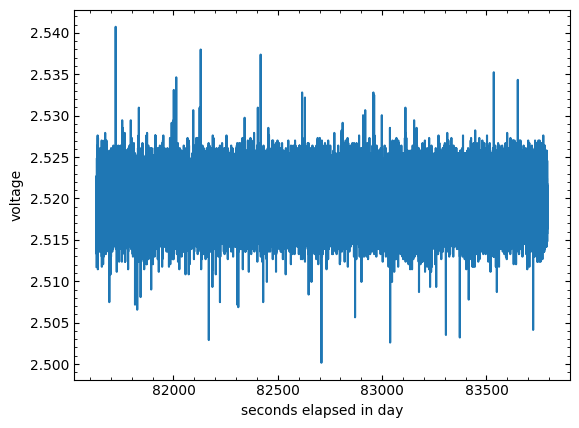

In [14]:
plt.plot(nomagSeconds,nomagVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

In [15]:
adjnomagVolt = nomagVolt - nomagVolt.mean()

Text(0, 0.5, 'voltage')

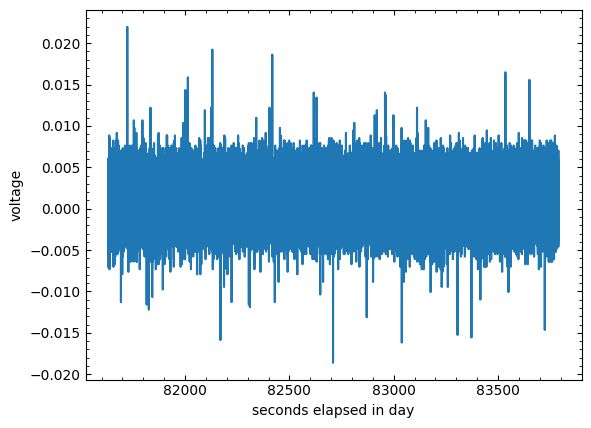

In [16]:
plt.plot(nomagSeconds,adjnomagVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

Text(0, 0.5, 'voltage')

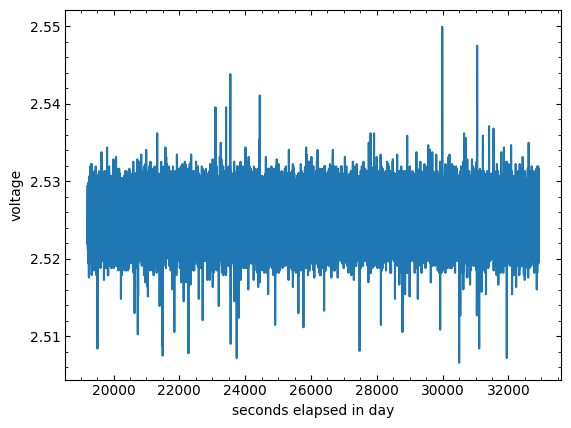

In [17]:
plt.plot(downoverSec,downoverVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

Text(0, 0.5, 'voltage')

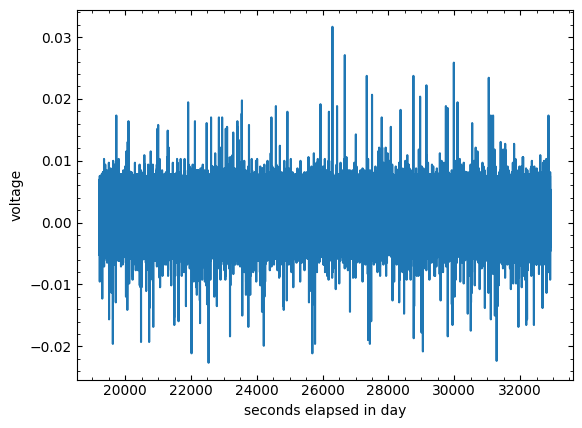

In [18]:
adjOverVolt = overVolt - overVolt.mean()
plt.plot(overSeconds,adjOverVolt)
plt.xlabel('seconds elapsed in day')
plt.ylabel('voltage')

In [19]:
fs = 100
nper = 300
magF, magPSD = sp.signal.welch(magVolt,fs=fs,nperseg=nper)
# nomagF, nomagPSD = sp.signal.welch(nomagSensor,fs=fs,nperseg=150)
overF,overPSD = sp.signal.welch(adjOverVolt,fs=fs,nperseg=nper)

nomagF,nomagPSD = sp.signal.welch(nomagVolt,fs=fs,nperseg=nper)

Text(0.5, 0, 'Hz')

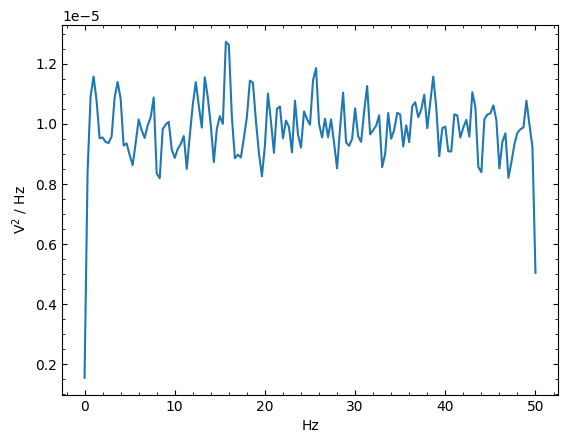

In [20]:
plt.plot(magF,magPSD)
# plt.plot(nomagF,nomagPSD)
plt.ylabel(r'V$^2$ / Hz')
plt.xlabel('Hz')

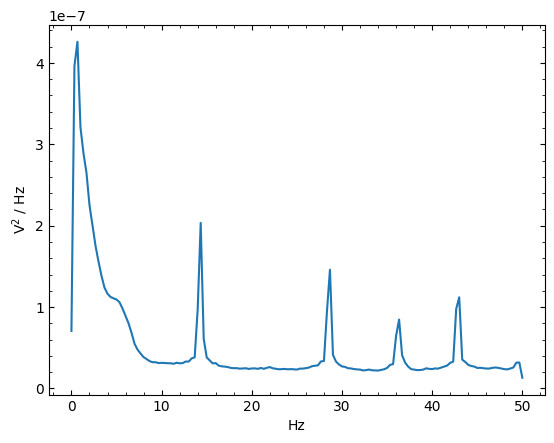

In [21]:
plt.plot(overF,overPSD)
plt.ylabel(r'V$^2$ / Hz')
plt.xlabel('Hz')
# plt.semilogx()
plt.show()

In [22]:
downF,downPSD = sp.signal.welch(downoverVolt,fs=20,nperseg=300)

Text(0.5, 0, 'Hz')

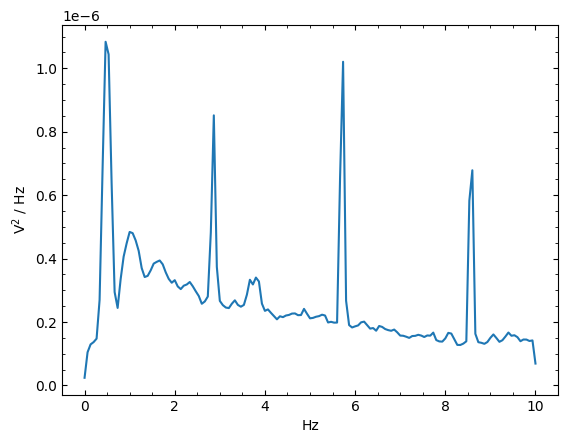

In [23]:
plt.plot(downF,downPSD)
plt.ylabel(r'V$^2$ / Hz')
plt.xlabel('Hz')

Text(0.5, 0, 'Hz')

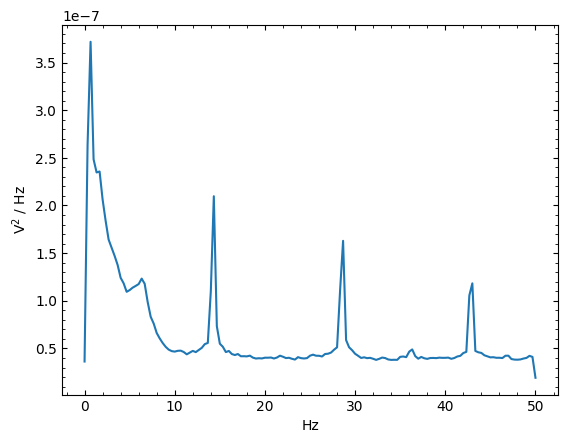

In [24]:
plt.plot(nomagF,nomagPSD)
plt.ylabel(r'V$^2$ / Hz')
plt.xlabel('Hz')

In [25]:
compPSD = overPSD - nomagPSD

Text(0.5, 0, 'Hz')

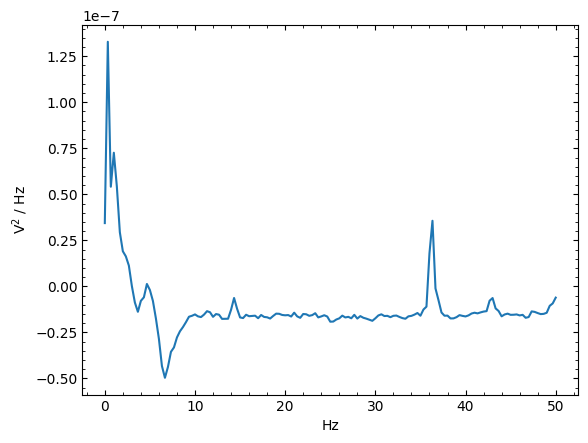

In [26]:
plt.plot(overF,compPSD)
plt.ylabel(r'V$^2$ / Hz')
plt.xlabel('Hz')